In [81]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [82]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("metadata.csv")

print("Dataset shape:", df.shape)
df.head()

Saving metadata.csv to metadata (1).csv
Dataset shape: (2298, 26)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [83]:
label_encoder = LabelEncoder()

y = df["diagnostic"].copy()

y_encoded = label_encoder.fit_transform(y)

print("Label encoder classes:")
print(label_encoder.classes_)

print("\nClass mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Label encoder classes:
['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']

Class mapping:
0 = ACK
1 = BCC
2 = MEL
3 = NEV
4 = SCC
5 = SEK


In [84]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("label_encoder.pkl saved.")

label_encoder.pkl saved.


In [85]:
numerical_cols = [
    "age",
    "fitspatrick",
    "diameter_1",
    "diameter_2"
]

categorical_cols = [
    "smoke",
    "drink",
    "background_father",
    "background_mother",
    "pesticide",
    "gender",
    "skin_cancer_history",
    "cancer_history",
    "has_piped_water",
    "has_sewage_system",
    "region",
    "itch",
    "grew",
    "hurt",
    "changed",
    "bleed",
    "elevation",
    "biopsed"
]

selected_cols = numerical_cols + categorical_cols

X = df[selected_cols].copy()

print("Selected features:", len(selected_cols))
print("Raw feature shape:", X.shape)

Selected features: 22
Raw feature shape: (2298, 22)


In [86]:
for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values handled.")
print("Total missing values:", X.isnull().sum().sum())

Missing values handled.
Total missing values: 0


/tmp/ipykernel_2345/361880115.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [87]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False
)

X = X.astype(float)

print("Final feature shape:", X.shape)

Final feature shape: (2298, 78)


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1838, 78)
X_test: (460, 78)
y_train: (1838,)
y_test: (460,)


In [89]:
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Scaling completed.")

Scaling completed.


In [90]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("scaler.pkl saved.")

scaler.pkl saved.


In [91]:
X_test_tensor = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_test tensor shape: torch.Size([460, 78])
y_test tensor shape: torch.Size([460])


In [92]:
# ==============================================================
# DEEPANN BASELINE MODEL
# ==============================================================

class DeepSkinDiseaseANN(nn.Module):

    def __init__(self, input_size=78, num_classes=6):
        super(DeepSkinDiseaseANN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


baseline_model = DeepSkinDiseaseANN(
   input_size=78,
    num_classes=6
)

print(baseline_model)

DeepSkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=6, bias=True)
  )
)


In [93]:
from google.colab import files

uploaded = files.upload()

Saving DermaVision_Module2_Final_DeepANN.pth to DermaVision_Module2_Final_DeepANN (1).pth


In [94]:
model = DeepSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

model.load_state_dict(
    torch.load(
        "DermaVision_Module2_Final_DeepANN.pth",
        map_location=torch.device("cpu"),
        weights_only=True
    )
)

model.eval()

print("Final DeepANN model loaded successfully.")

Final DeepANN model loaded successfully.


In [95]:
model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    predicted_labels = torch.argmax(
        outputs,
        dim=1
    )

predicted_labels = predicted_labels.numpy()

print("Predictions generated successfully.")

print("First 10 predictions:")
print(predicted_labels[:10])

Predictions generated successfully.
First 10 predictions:
[1 1 0 3 3 0 1 5 1 3]


In [96]:
predicted_names = label_encoder.inverse_transform(
    predicted_labels
)

actual_names = label_encoder.inverse_transform(
    y_test
)

print("First 10 actual:")
print(actual_names[:10])

print("\nFirst 10 predicted:")
print(predicted_names[:10])

First 10 actual:
['BCC' 'BCC' 'ACK' 'NEV' 'ACK' 'ACK' 'BCC' 'SEK' 'BCC' 'NEV']

First 10 predicted:
['BCC' 'BCC' 'ACK' 'NEV' 'NEV' 'ACK' 'BCC' 'SEK' 'BCC' 'NEV']


In [97]:
accuracy = accuracy_score(
    actual_names,
    predicted_names
)

print(
    f"Prediction Accuracy: {accuracy * 100:.2f}%"
)

Prediction Accuracy: 76.09%


In [98]:
report = classification_report(
    actual_names,
    predicted_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         ACK     0.7806    0.8288    0.8040       146
         BCC     0.7895    0.8876    0.8357       169
         MEL     1.0000    0.4000    0.5714        10
         NEV     0.6613    0.8367    0.7387        49
         SCC     0.5294    0.2308    0.3214        39
         SEK     0.7812    0.5319    0.6329        47

    accuracy                         0.7609       460
   macro avg     0.7570    0.6193    0.6507       460
weighted avg     0.7547    0.7609    0.7452       460



In [99]:
cm = confusion_matrix(
    actual_names,
    predicted_names,
    labels=label_encoder.classes_
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[121  13   0   5   2   5]
 [ 12 150   0   2   5   0]
 [  1   2   4   2   1   0]
 [  2   4   0  41   0   2]
 [  9  21   0   0   9   0]
 [ 10   0   0  12   0  25]]


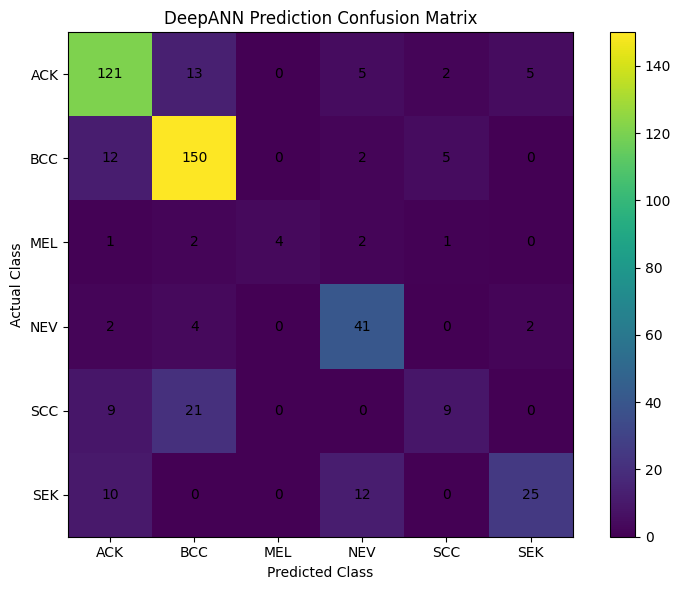

In [100]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("DeepANN Prediction Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [101]:
prediction_results = pd.DataFrame({
    "Actual": actual_names,
    "Predicted": predicted_names
})

prediction_results.head(10)

,Actual,Predicted
0,BCC,BCC
1,BCC,BCC
2,ACK,ACK
3,NEV,NEV
4,ACK,NEV
5,ACK,ACK
6,BCC,BCC
7,SEK,SEK
8,BCC,BCC
9,NEV,NEV


In [102]:
prediction_results.to_csv(
    "DeepANN_Predictions.csv",
    index=False
)

print("Prediction CSV saved successfully.")

Prediction CSV saved successfully.


In [103]:
with open(
    "Classification_Report.txt",
    "w"
) as f:

    f.write(report)

print("Classification report saved.")

Classification report saved.


In [107]:
from google.colab import files

files.download("DeepANN_Predictions.csv")
files.download("Classification_Report.txt")
files.download("Confusion_Matrix.png")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>